# Тема №9: Авто-обработчик жалоб и претензий

## Описание

Цель работы — создать программное обеспечение, которое способно систематизировать обращения потребителей, анализировать жалобы и претензии, определять самые частые проблемы и давать обратную связь организациям для оперативного реагирования.

## Методология

Проекты основаны на методах тематического моделирования (Topic Modeling) с использованием Latent Dirichlet Allocation (LDA) и алгоритмах кластеризации (Clustering, k-means).

## Результаты

Полученная система помогает оперативно реагировать на возникающие запросы, повышать качество обслуживания и формировать полезные стратегии развития бизнеса.

## Метрики оценки

- Success rate по определению ключевых проблем
- Сокращение среднего времени отклика на жалобу (average response time reduction)
- Recall (полнота)

Доля жалоб, которые система смогла правильно отнести к соответствующим категориям.
- Precision (точность)
Доля правильно отнесённых жалоб среди всех классифицированных системой.
- F1-Score (баланс точности и полноты)


Гармонизированная величина, объединяющая показатели точности и полноты.
- Topical Diversity (разнообразие категорий)

Широту спектра решаемых проблем и точность распределения по разным категориям.
- Redundancy Rate (повторяемость)

Показатель, характеризующий частоту дублирования одной и той же проблемы разными пользователями.
- Problem Resolution Rate (скорость разрешения проблем)

Сколько процентов проблем решается в пределах установленного срока после поступления жалобы.

## 1. Установка библиотек

In [ ]:
!pip install -q datasets transformers accelerate evaluate nltk wordcloud tqdm scikit-learn seaborn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install -q kagglehub[pandas-datasets]

## 2. Импорт библиотек

In [ ]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from tqdm.auto import tqdm
from wordcloud import WordCloud
from collections import Counter

from datasets import load_dataset
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score, adjusted_rand_score, normalized_mutual_info_score, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"
tqdm.pandas()

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## 3. Загрузка датасета

In [ ]:
import time
import kagglehub
from kagglehub import KaggleDatasetAdapter

start = time.time()

df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "namigabbasov/consumer-complaint-dataset",
    "complaints.csv"
)

print(df_raw.shape)
print(df_raw.columns.tolist())
print("time:", round(time.time() - start, 2))

df_raw.head()

100%|██████████| 669M/669M [00:40<00:00, 17.4MB/s]

Extracting zip of complaints.csv...


(2023066, 11)
['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Timely response?']
time: 93.45


,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes
3,271,Credit Reporting,Subject : Dispute of Inaccurate Information on...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Improper use of your report,Reporting company used your report improperly,CORELOGIC INC,GA,Yes
4,276,Loans,They allowed me to use the account for about a...,"Payday loan, title loan, personal loan, or adv...",2024-07-26,Payday loan,Received a loan you didn't apply for,NaN,MoneyLion Inc.,PA,Yes


## 4. Подготовка колонок

In [ ]:
df = df_raw.copy()

df = df.rename(columns={
    "narrative": "text",
    "product_5": "category",
    "Issue": "issue",
    "Company": "company",
    "Date received": "date"
})

df = df[["text", "category", "issue", "company", "date"]].dropna()
df = df[df["text"].astype(str).str.len() > 50]

df = df.groupby("category").sample(n=1000, random_state=42)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(5000, 5)


,text,category,issue,company,date
0,Im not sure if the specific dates. Ill have to...,Credit Card Services,"Advertising and marketing, including promotion...","Credit Karma, LLC",2022-10-10
1,On XX/XX/2022 I contacted Experian about the f...,Credit Reporting,Problem with a credit reporting company's inve...,Experian Information Solutions Inc.,2023-01-16
2,Good day! I am asking requesting for your assi...,Credit Reporting,Problem with a company's investigation into an...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2023-12-06
3,OK so my mom had XXXX when XXXX very first st...,Credit Card Services,Problem with a purchase shown on your statement,"CITIBANK, N.A.",2022-04-03
4,I would be overdrawn in one bank account trans...,Bank Accounts and Services,Problem caused by your funds being low,WELLS FARGO & COMPANY,2023-01-22


## 5. Балансировка и ограничение выборки

In [ ]:
TOP_CLASSES = 6
N_PER_CLASS = 800

top_categories = df["category"].value_counts().head(TOP_CLASSES).index.tolist()
df = df[df["category"].isin(top_categories)].copy()

df = df.groupby("category", group_keys=False).apply(
    lambda x: x.sample(min(len(x), N_PER_CLASS), random_state=RANDOM_STATE)
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])
N_CLASSES = len(le.classes_)

print(f"Итоговая выборка: {len(df):,}")
print(f"Классов: {N_CLASSES}")
print(list(le.classes_))
print(df["category"].value_counts())

Итоговая выборка: 4,000
Классов: 5
['Bank Accounts and Services', 'Credit Card Services', 'Credit Reporting', 'Debt Collection', 'Loans']
category
Bank Accounts and Services    800
Loans                         800
Debt Collection               800
Credit Reporting              800
Credit Card Services          800
Name: count, dtype: int64


## 6. EDA

In [ ]:
df["word_count"] = df["text"].astype(str).str.split().str.len()

print(df[["text", "word_count"]].head())

                                                text  word_count
0  I have been debited for an old acct that was c...          43
1  I was financing a car with  Heritage Acceptanc...         253
2  Received a letter dated XXXX XXXX, 2015 statin...         185
3  Since XXXX of XXXX, after hardships related to...         562
4  Thunderbird collections ( TCS ) XXXX XXXX XXXX...          80


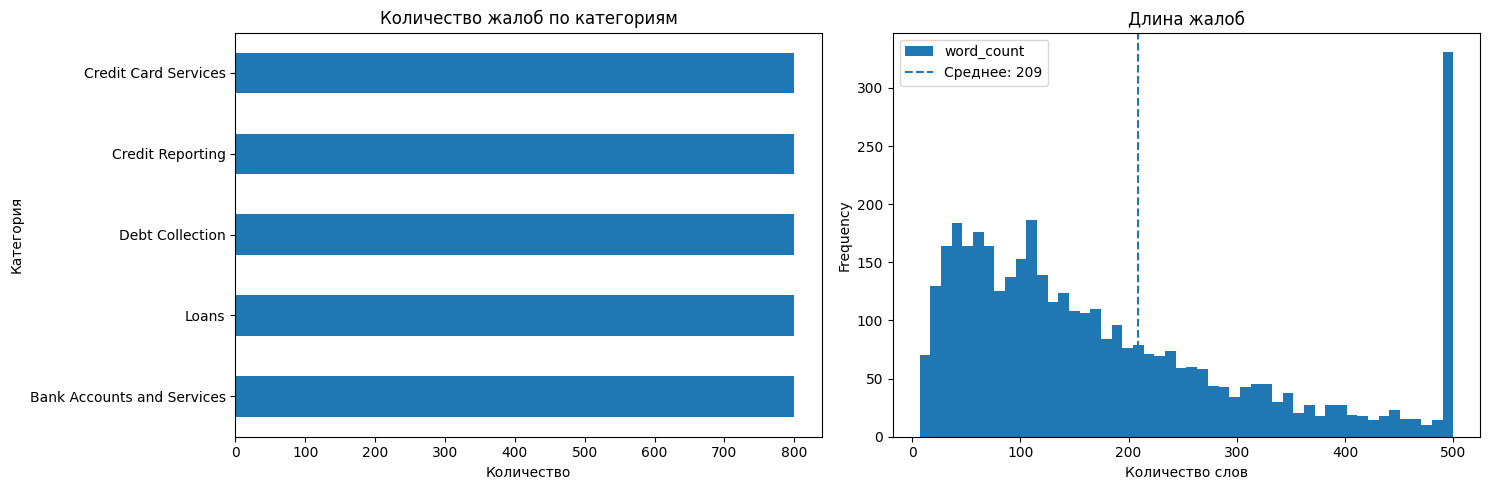

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df["category"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Количество жалоб по категориям")
axes[0].set_xlabel("Количество")
axes[0].set_ylabel("Категория")

df["word_count"].clip(upper=500).plot(kind="hist", bins=50, ax=axes[1])
axes[1].axvline(df["word_count"].mean(), linestyle="--", label=f"Среднее: {df['word_count'].mean():.0f}")
axes[1].set_title("Длина жалоб")
axes[1].set_xlabel("Количество слов")
axes[1].legend()

plt.tight_layout()
plt.show()

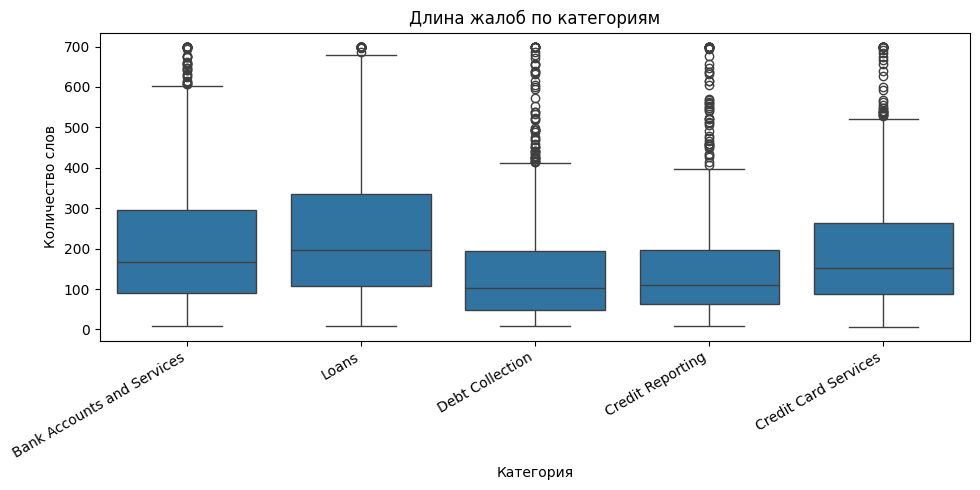

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="category", y=df["word_count"].clip(upper=700))
plt.title("Длина жалоб по категориям")
plt.xlabel("Категория")
plt.ylabel("Количество слов")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

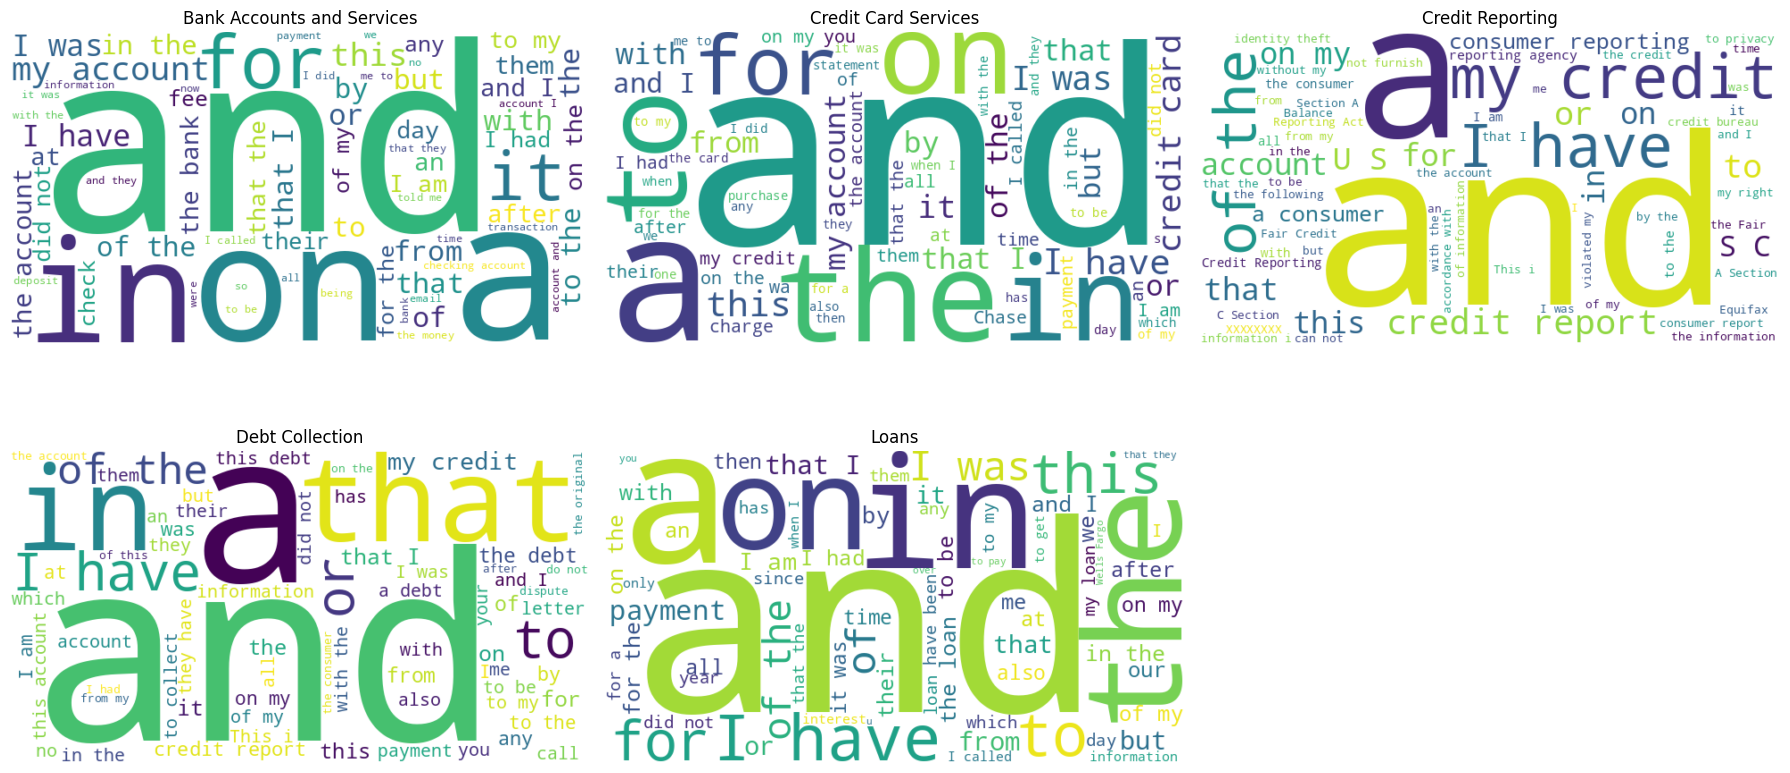

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, cat in enumerate(le.classes_):
    text = " ".join(df[df["category"] == cat]["text"].head(400))
    wc = WordCloud(width=650, height=350, background_color="white", max_words=70, stopwords={"xxxx", "xx"}).generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(cat)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Предобработка текста

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"xxxx", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["processed"] = df["text"].progress_apply(clean_text)
df = df[df["processed"].str.len() > 30].reset_index(drop=True)

df[["category", "text", "processed"]].head()

  0%|          | 0/4000 [00:00<?, ?it/s]

,category,text,processed
0,Bank Accounts and Services,I have been debited for an old acct that was c...,i have been debited for an old acct that was c...
1,Loans,I was financing a car with Heritage Acceptanc...,i was financing a car with heritage acceptance...
2,Bank Accounts and Services,"Received a letter dated XXXX XXXX, 2015 statin...",received a letter dated stating my chase credi...
3,Loans,"Since XXXX of XXXX, after hardships related to...",since of after hardships related to covid and ...
4,Debt Collection,Thunderbird collections ( TCS ) XXXX XXXX XXXX...,thunderbird collections tcs az a medical debt ...


## 8. Разбивка и векторизация

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["processed"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=RANDOM_STATE
)

X_train_text, X_val_text, y_train_text, y_val_text = train_test_split(
    X_train.tolist(),
    y_train.tolist(),
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

X_test_text = X_test.tolist()
y_test_text = y_test.tolist()

tfidf = TfidfVectorizer(max_features=9000, ngram_range=(1, 2), sublinear_tf=True, stop_words="english", min_df=3, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(tqdm(X_train, desc="TF-IDF train"))
X_test_tfidf = tfidf.transform(tqdm(X_test, desc="TF-IDF test"))

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = ros.fit_resample(X_train_tfidf, y_train)

count_vec = CountVectorizer(max_features=6000, stop_words="english", min_df=5, max_df=0.85)
X_count = count_vec.fit_transform(tqdm(df["processed"], desc="CountVectorizer"))

print(f"Train: {X_train_tfidf.shape}")
print(f"Test: {X_test_tfidf.shape}")
print(f"Balanced train: {X_train_bal.shape}")
print(f"До балансировки: {dict(sorted(Counter(y_train).items()))}")
print(f"После балансировки: {dict(sorted(Counter(y_train_bal).items()))}")

TF-IDF train:   0%|          | 0/3199 [00:00<?, ?it/s]

TF-IDF test:   0%|          | 0/800 [00:00<?, ?it/s]

CountVectorizer:   0%|          | 0/3999 [00:00<?, ?it/s]

Train: (3199, 9000)
Test: (800, 9000)
Balanced train: (3200, 9000)
До балансировки: {0: 640, 1: 640, 2: 639, 3: 640, 4: 640}
После балансировки: {0: 640, 1: 640, 2: 640, 3: 640, 4: 640}


## 9. LDA — тематическое моделирование

In [ ]:
N_TOPICS = N_CLASSES

start = time.time()
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE, max_iter=20, learning_method="online", verbose=1)
lda_matrix = lda.fit_transform(X_count)
print("time:", round(time.time() - start, 2))

feature_names = count_vec.get_feature_names_out()
topic_keywords = {}

for i, topic in enumerate(lda.components_):
    words = [feature_names[j] for j in topic.argsort()[:-13:-1]]
    topic_keywords[i] = words
    print(f"Топик {i}: {', '.join(words[:10])}")

df["lda_topic"] = lda_matrix.argmax(axis=1)

iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20
time: 24.68
Топик 0: credit, consumer, report, information, reporting, account, section, accounts, agency, identity
Топик 1: card, credit, xx, account, bank, fraud, chase, dispute, received, did
Топик 2: xx, debt, credit, account, information, collection, date, report, inquiry, company
Топик 3: xx, loan, payment, mortgage, payments, time, home, pay, received, did
Топик 4: xx, account, bank, money, told, ca

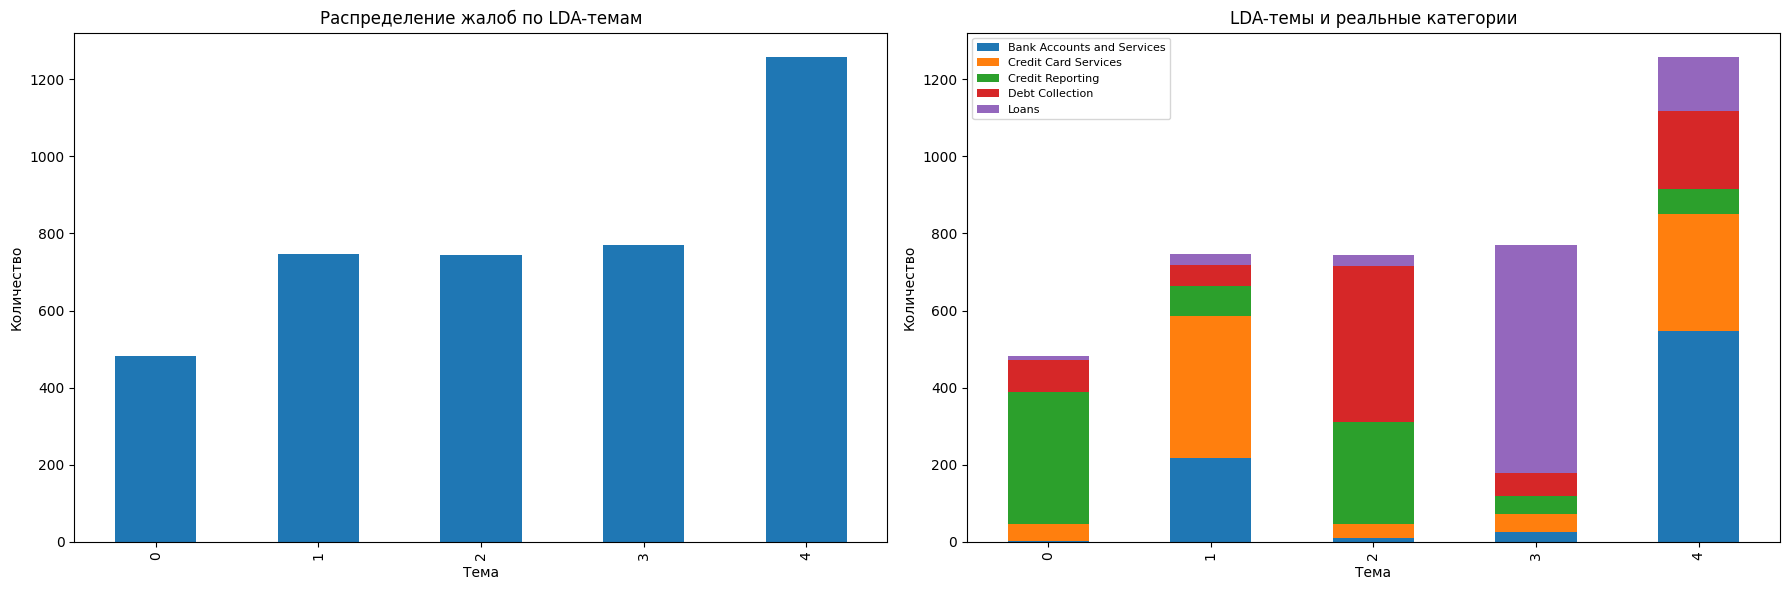

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df["lda_topic"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение жалоб по LDA-темам")
axes[0].set_xlabel("Тема")
axes[0].set_ylabel("Количество")

pd.crosstab(df["lda_topic"], df["category"]).plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("LDA-темы и реальные категории")
axes[1].set_xlabel("Тема")
axes[1].set_ylabel("Количество")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

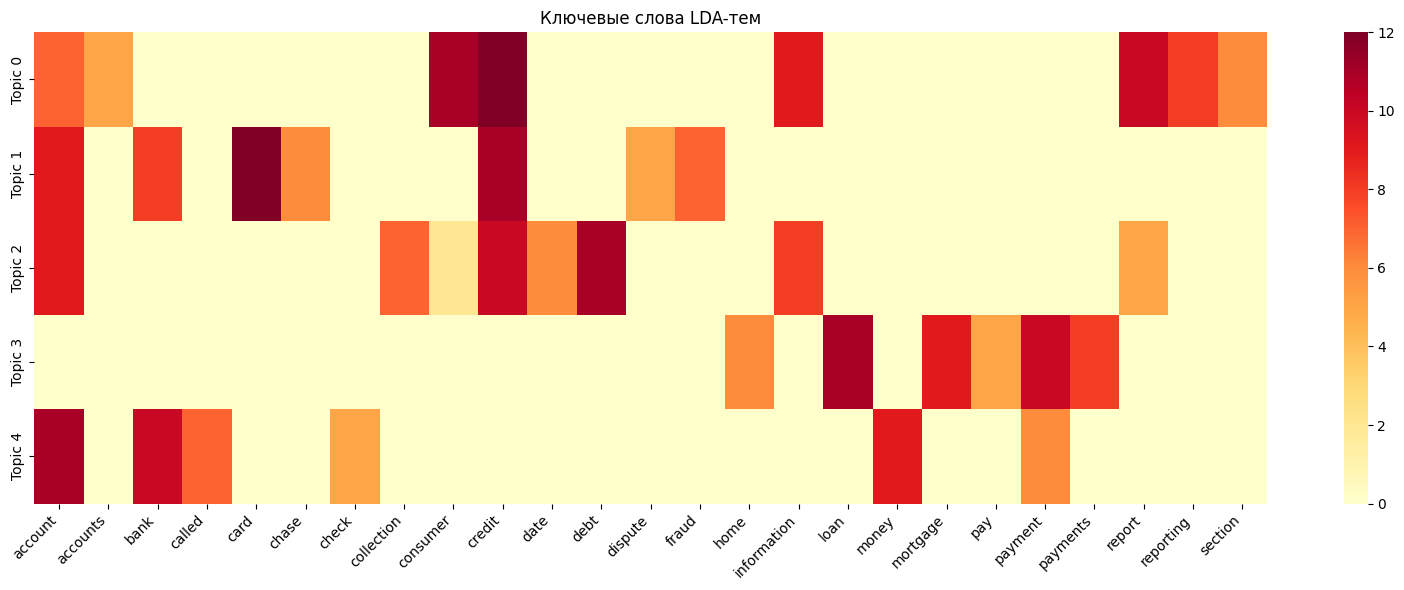

In [ ]:
topic_words = sorted(set(sum([v[:8] for v in topic_keywords.values()], [])))[:25]
mat = np.zeros((N_TOPICS, len(topic_words)))

for i in range(N_TOPICS):
    for j, w in enumerate(topic_words):
        if w in topic_keywords[i]:
            mat[i, j] = len(topic_keywords[i]) - topic_keywords[i].index(w)

plt.figure(figsize=(16, 6))
sns.heatmap(mat, xticklabels=topic_words, yticklabels=[f"Topic {i}" for i in range(N_TOPICS)], cmap="YlOrRd")
plt.title("Ключевые слова LDA-тем")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. K-Means — кластеризация

Elbow:   0%|          | 0/11 [00:00<?, ?it/s]

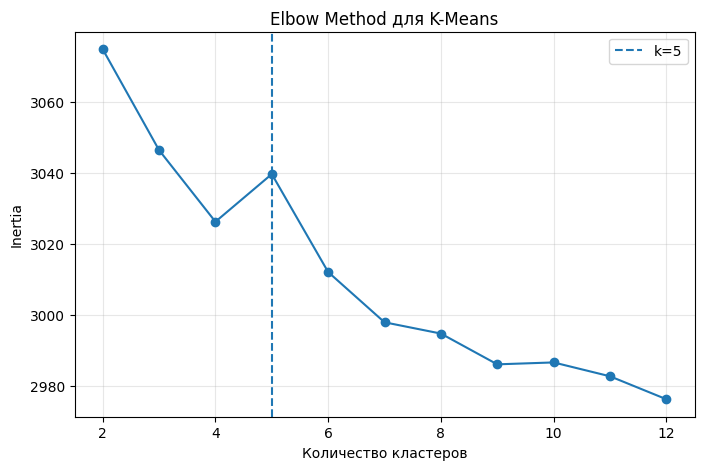

In [ ]:
inertias = []
ks = range(2, 13)

for k in tqdm(ks, desc="Elbow"):
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=512)
    km.fit(X_train_tfidf)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, marker="o")
plt.axvline(N_CLASSES, linestyle="--", label=f"k={N_CLASSES}")
plt.title("Elbow Method для K-Means")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
N_CLUSTERS = N_CLASSES
X_full_tfidf = tfidf.transform(df["processed"])

start = time.time()
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10, batch_size=512)
df["cluster"] = kmeans.fit_predict(X_full_tfidf)
print("time:", round(time.time() - start, 2))

cluster_to_cat = {c: df[df["cluster"] == c]["category"].mode()[0] for c in range(N_CLUSTERS)}
df["kmeans_pred_category"] = df["cluster"].map(cluster_to_cat)
df["kmeans_pred_label"] = le.transform(df["kmeans_pred_category"])

sample_size = min(2500, len(df))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), sample_size, replace=False)

sil = silhouette_score(X_full_tfidf[sample_idx], df["cluster"].iloc[sample_idx], metric="cosine")
ari = adjusted_rand_score(df["label"], df["cluster"])
nmi = normalized_mutual_info_score(df["label"], df["cluster"])

print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

pd.DataFrame({
    "cluster": range(N_CLUSTERS),
    "main_category": [cluster_to_cat[c] for c in range(N_CLUSTERS)],
    "size": [(df["cluster"] == c).sum() for c in range(N_CLUSTERS)]
})

time: 0.23
Silhouette Score: 0.0213
Adjusted Rand Index: 0.2263
Normalized Mutual Information: 0.3068


,cluster,main_category,size
0,0,Credit Reporting,118
1,1,Debt Collection,950
2,2,Bank Accounts and Services,603
3,3,Loans,1661
4,4,Credit Reporting,667


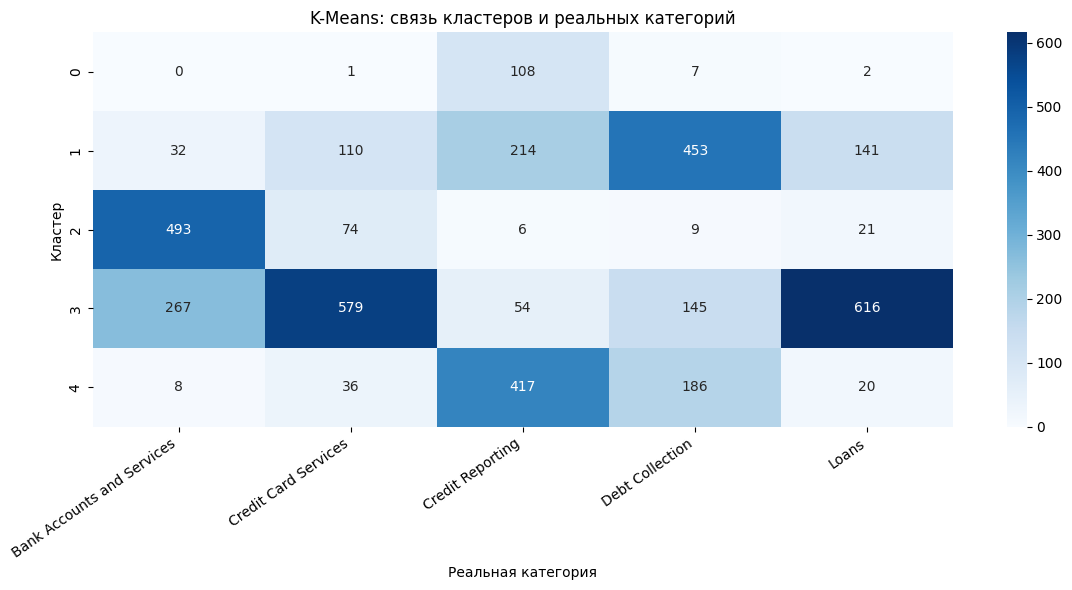

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pd.crosstab(df["cluster"], df["category"]), annot=True, fmt="d", cmap="Blues")
plt.title("K-Means: связь кластеров и реальных категорий")
plt.xlabel("Реальная категория")
plt.ylabel("Кластер")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

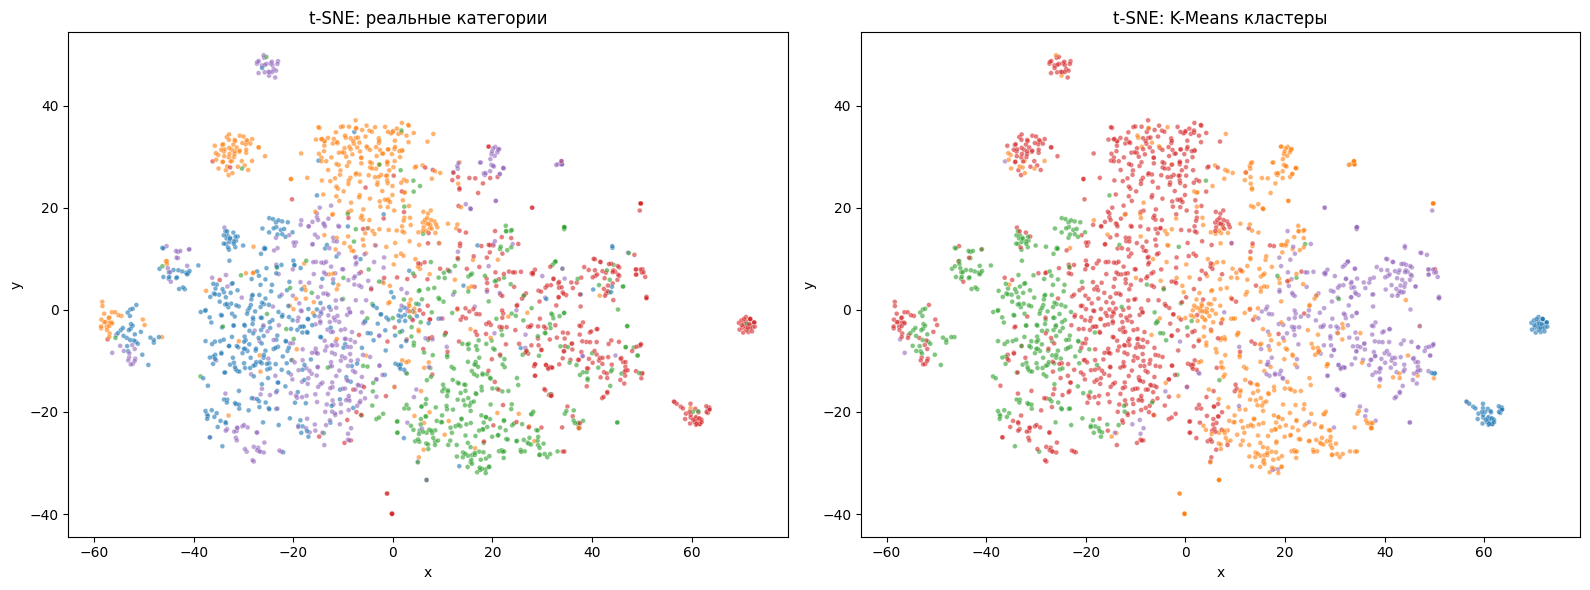

In [ ]:
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_full_tfidf)

plot_n = min(2000, len(df))
X_tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, learning_rate="auto", init="pca").fit_transform(X_svd[:plot_n])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["category"].iloc[:plot_n], s=12, alpha=0.6, ax=axes[0], legend=False)
axes[0].set_title("t-SNE: реальные категории")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["cluster"].iloc[:plot_n], palette="tab10", s=12, alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title("t-SNE: K-Means кластеры")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

## 11. ML-классификаторы

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=4, solver="saga", class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "LinearSVC": CalibratedClassifierCV(LinearSVC(max_iter=3000, C=1.0, class_weight="balanced", random_state=RANDOM_STATE)),
    "Naive Bayes": MultinomialNB(alpha=0.1)
}

results = {}

for name, model_ml in tqdm(models.items(), desc="Training ML models"):
    start = time.time()
    model_ml.fit(X_train_bal, y_train_bal)
    y_pred = model_ml.predict(X_test_tfidf)
    y_prob = model_ml.predict_proba(X_test_tfidf) if hasattr(model_ml, "predict_proba") else None
    results[name] = {
        "model": model_ml,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "time": round(time.time() - start, 2)
    }

pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "time"]].sort_values("f1", ascending=False)

Training ML models:   0%|          | 0/3 [00:00<?, ?it/s]

,accuracy,precision,recall,f1,time
Logistic Regression,0.835,0.834819,0.835,0.833934,0.33
LinearSVC,0.8275,0.826984,0.8275,0.825922,0.63
Naive Bayes,0.81,0.811185,0.81,0.807703,0.02


<Figure size 1000x500 with 0 Axes>

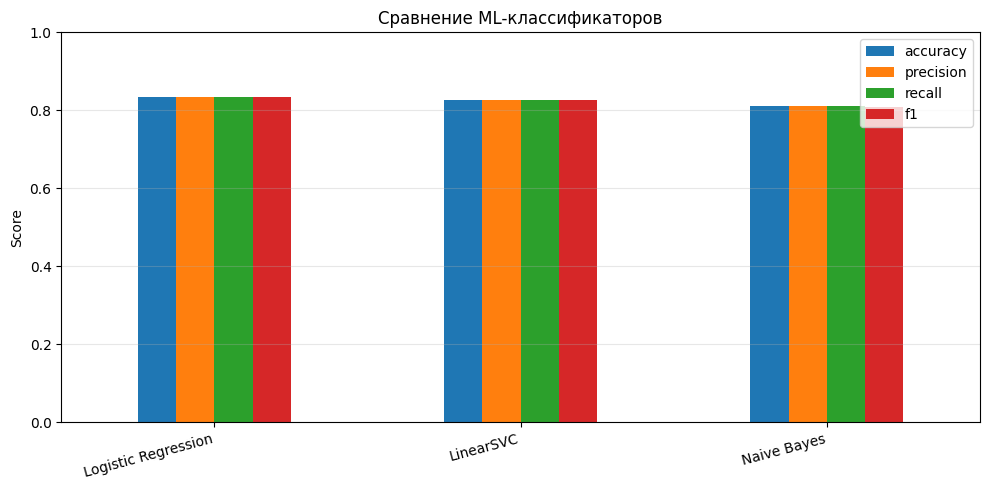

In [ ]:
ml_metrics = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]].sort_values("f1", ascending=False)

plt.figure(figsize=(10, 5))
ml_metrics.plot(kind="bar", figsize=(10, 5))
plt.title("Сравнение ML-классификаторов")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. DistilBERT на GPU

In [ ]:
model_name = "distilbert-base-uncased"
MAX_LEN = 128
EPOCHS = 3
BATCH_SIZE = 8

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_enc = tokenizer(X_train_text, truncation=True, padding=True, max_length=MAX_LEN)
val_enc = tokenizer(X_val_text, truncation=True, padding=True, max_length=MAX_LEN)
test_enc = tokenizer(X_test_text, truncation=True, padding=True, max_length=MAX_LEN)

class ComplaintDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = ComplaintDataset(train_enc, y_train_text)
val_ds = ComplaintDataset(val_enc, y_val_text)
test_ds = ComplaintDataset(test_enc, y_test_text)

bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=N_CLASSES).to(DEVICE)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0)
    }

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
import inspect

params = inspect.signature(TrainingArguments.__init__).parameters
print(params.keys())

odict_keys(['self', 'output_dir', 'do_train', 'do_eval', 'do_predict', 'eval_strategy', 'prediction_loss_only', 'per_device_train_batch_size', 'per_device_eval_batch_size', 'gradient_accumulation_steps', 'eval_accumulation_steps', 'eval_delay', 'torch_empty_cache_steps', 'learning_rate', 'weight_decay', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'max_grad_norm', 'num_train_epochs', 'max_steps', 'lr_scheduler_type', 'lr_scheduler_kwargs', 'warmup_ratio', 'warmup_steps', 'log_level', 'log_level_replica', 'log_on_each_node', 'logging_dir', 'logging_strategy', 'logging_first_step', 'logging_steps', 'logging_nan_inf_filter', 'save_strategy', 'save_steps', 'save_total_limit', 'enable_jit_checkpoint', 'save_on_each_node', 'save_only_model', 'restore_callback_states_from_checkpoint', 'use_cpu', 'seed', 'data_seed', 'bf16', 'fp16', 'bf16_full_eval', 'fp16_full_eval', 'tf32', 'local_rank', 'ddp_backend', 'debug', 'dataloader_drop_last', 'eval_steps', 'dataloader_num_workers', 'dataloader_prefet

In [ ]:
args_dict = {
    "output_dir": "./complaints_distilbert",
    "save_strategy": "epoch",
    "logging_strategy": "epoch",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE * 2,
    "num_train_epochs": EPOCHS,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "report_to": "none",
    "fp16": torch.cuda.is_available(),
    "seed": RANDOM_STATE
}

if "eval_strategy" in params:
    args_dict["eval_strategy"] = "epoch"
elif "evaluation_strategy" in params:
    args_dict["evaluation_strategy"] = "epoch"

args_dict = {k: v for k, v in args_dict.items() if k in params}

training_args = TrainingArguments(**args_dict)

In [ ]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

start = time.time()
trainer.train()
print("time:", round(time.time() - start, 2))

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.018622,0.684799,0.771875,0.774866,0.771875,0.770645
2,0.596950,0.619967,0.803125,0.810580,0.803125,0.804062
3,0.440585,0.614583,0.810937,0.810738,0.810937,0.810660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


time: 70.34


## 13. Метрики DistilBERT по эпохам

In [ ]:
logs = pd.DataFrame(trainer.state.log_history)
logs

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.018622,8.431919,1.335417e-05,1.0,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,320,0.684799,0.771875,0.774866,0.771875,0.770645,0.7097,901.831,56.364,NaN,NaN,NaN,NaN,NaN
2,0.596950,7.132290,6.687500e-06,2.0,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,640,0.619967,0.803125,0.810580,0.803125,0.804062,0.6261,1022.210,63.888,NaN,NaN,NaN,NaN,NaN
4,0.440585,7.324743,2.083333e-08,3.0,960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,960,0.614583,0.810937,0.810738,0.810937,0.810660,0.6641,963.782,60.236,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.934,109.775,13.727,2.542517e+14,0.685386


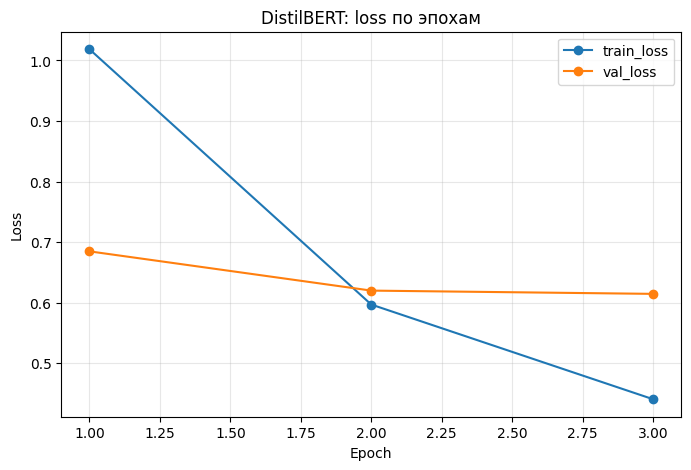

In [ ]:
train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]
eval_logs = logs[logs["eval_loss"].notna()][["epoch", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]]

plt.figure(figsize=(8, 5))
plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="train_loss")
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="val_loss")
plt.title("DistilBERT: loss по эпохам")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Тестирование DistilBERT

In [ ]:
start = time.time()
bert_pred = trainer.predict(test_ds)
bert_logits = bert_pred.predictions
bert_probs = torch.softmax(torch.tensor(bert_logits), dim=1).numpy()
bert_y_pred = np.argmax(bert_logits, axis=1)
print("time:", round(time.time() - start, 2))

results["DistilBERT"] = {
    "model": trainer,
    "y_pred": bert_y_pred,
    "y_prob": bert_probs,
    "accuracy": accuracy_score(y_test_text, bert_y_pred),
    "precision": precision_score(y_test_text, bert_y_pred, average="weighted", zero_division=0),
    "recall": recall_score(y_test_text, bert_y_pred, average="weighted", zero_division=0),
    "f1": f1_score(y_test_text, bert_y_pred, average="weighted", zero_division=0),
    "time": round(time.time() - start, 2)
}

pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "time"]].sort_values("f1", ascending=False)

time: 0.88


,accuracy,precision,recall,f1,time
Logistic Regression,0.835,0.834819,0.835,0.833934,0.33
LinearSVC,0.8275,0.826984,0.8275,0.825922,0.63
Naive Bayes,0.81,0.811185,0.81,0.807703,0.02
DistilBERT,0.795,0.7956,0.795,0.793132,0.88


## 15. Classification Report

In [ ]:
best_name = max(results, key=lambda k: results[k]["f1"])

print(f"Лучшая модель: {best_name}")
print(f"F1: {results[best_name]['f1']:.4f}")
print()

print(
    classification_report(
        y_test,
        results[best_name]["y_pred"],
        target_names=le.classes_,
        zero_division=0
    )
)

Лучшая модель: Logistic Regression
F1: 0.8339

                            precision    recall  f1-score   support

Bank Accounts and Services       0.85      0.91      0.88       160
      Credit Card Services       0.80      0.82      0.81       160
          Credit Reporting       0.84      0.81      0.83       160
           Debt Collection       0.83      0.74      0.78       160
                     Loans       0.85      0.89      0.87       160

                  accuracy                           0.83       800
                 macro avg       0.83      0.83      0.83       800
              weighted avg       0.83      0.83      0.83       800



## 16. Confusion Matrix

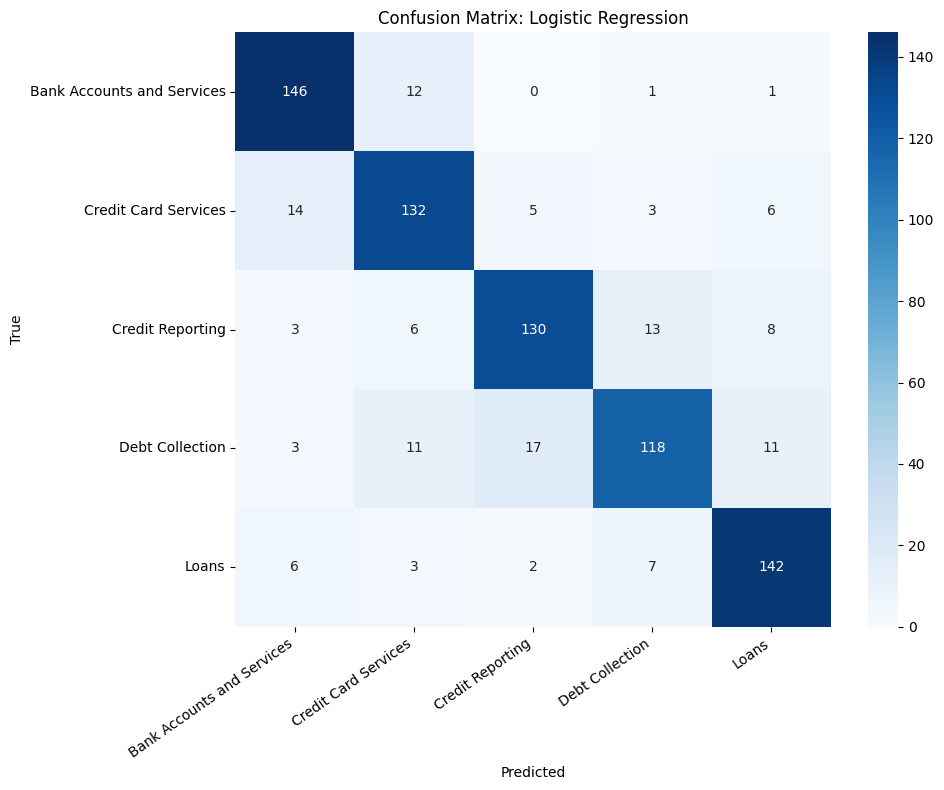

In [ ]:
cm = confusion_matrix(y_test, results[best_name]["y_pred"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

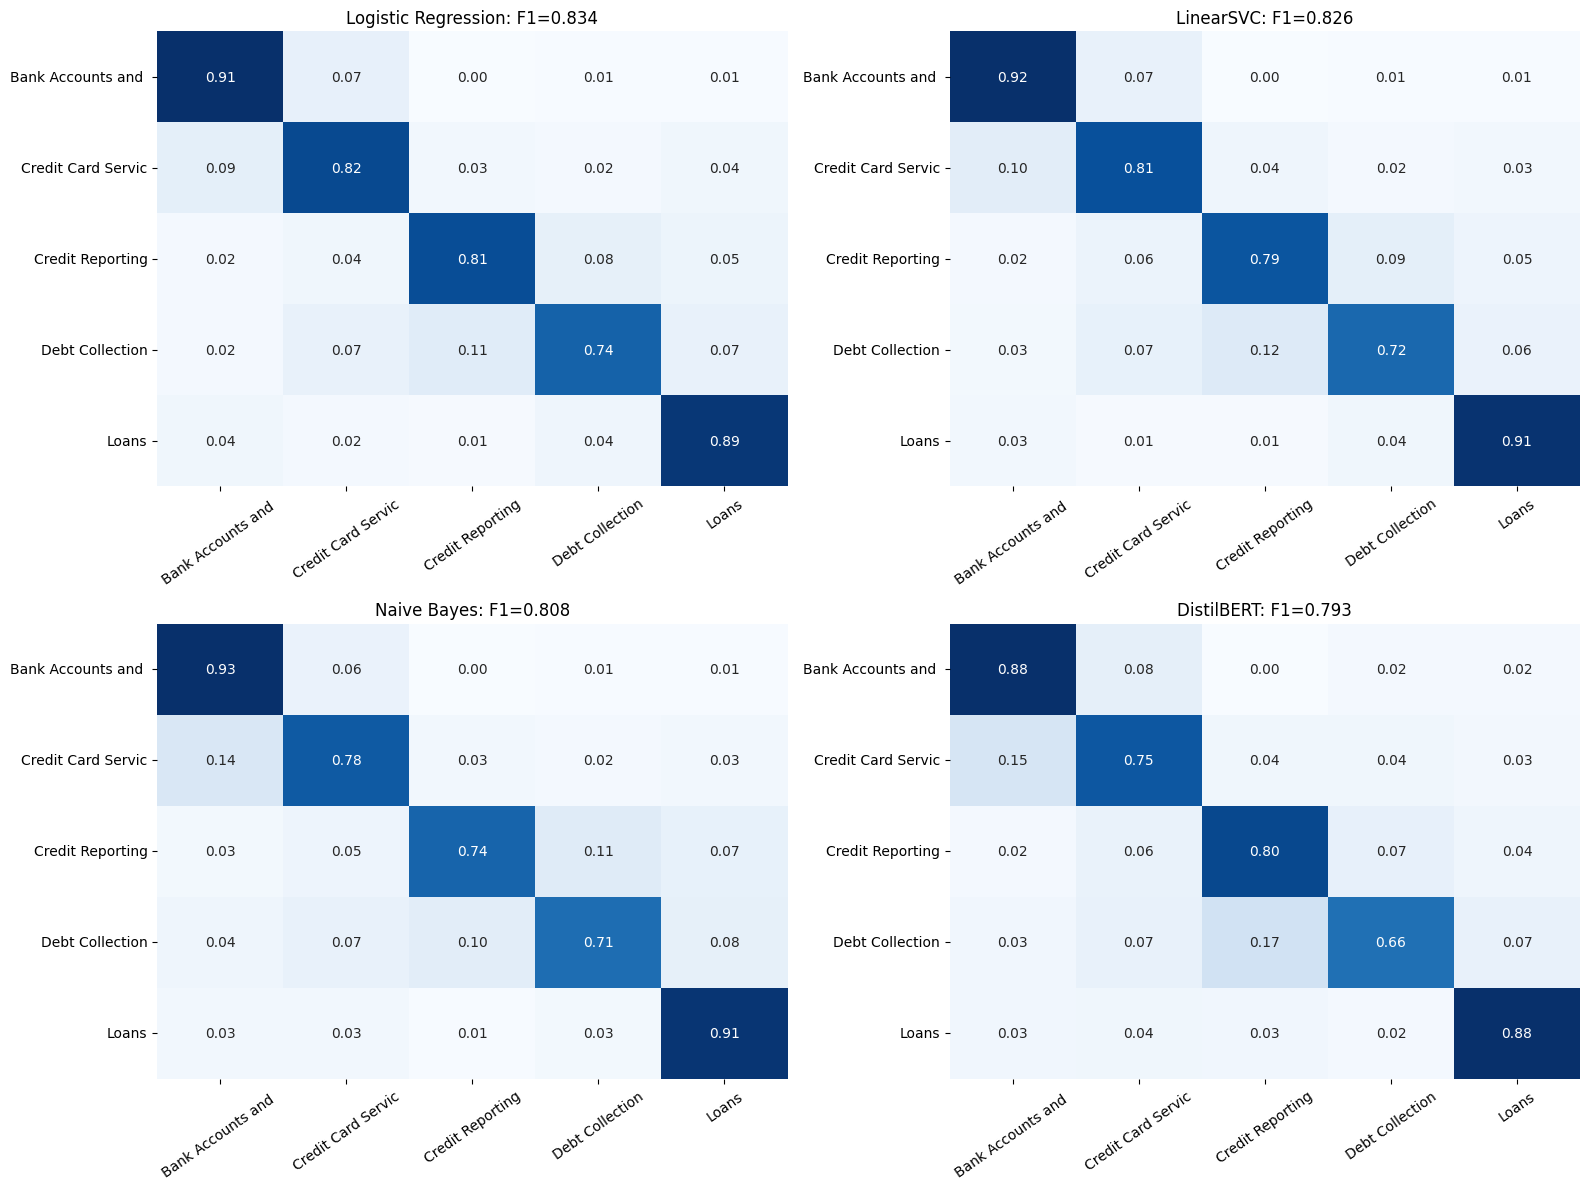

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"]).astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[c[:18] for c in le.classes_], yticklabels=[c[:18] for c in le.classes_], ax=ax, cbar=False)
    ax.set_title(f"{name}: F1={res['f1']:.3f}")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 17. ROC-AUC

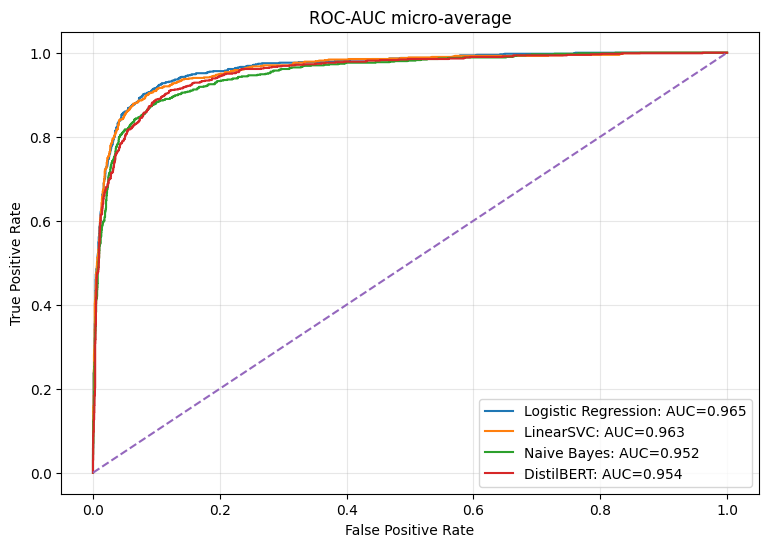

In [ ]:
y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))

plt.figure(figsize=(9, 6))

for name, res in results.items():
    if res["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), res["y_prob"].ravel())
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name}: AUC={auc_val:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC-AUC micro-average")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 18. Кривые обучения классических моделей

Learning curves:   0%|          | 0/3 [00:00<?, ?it/s]

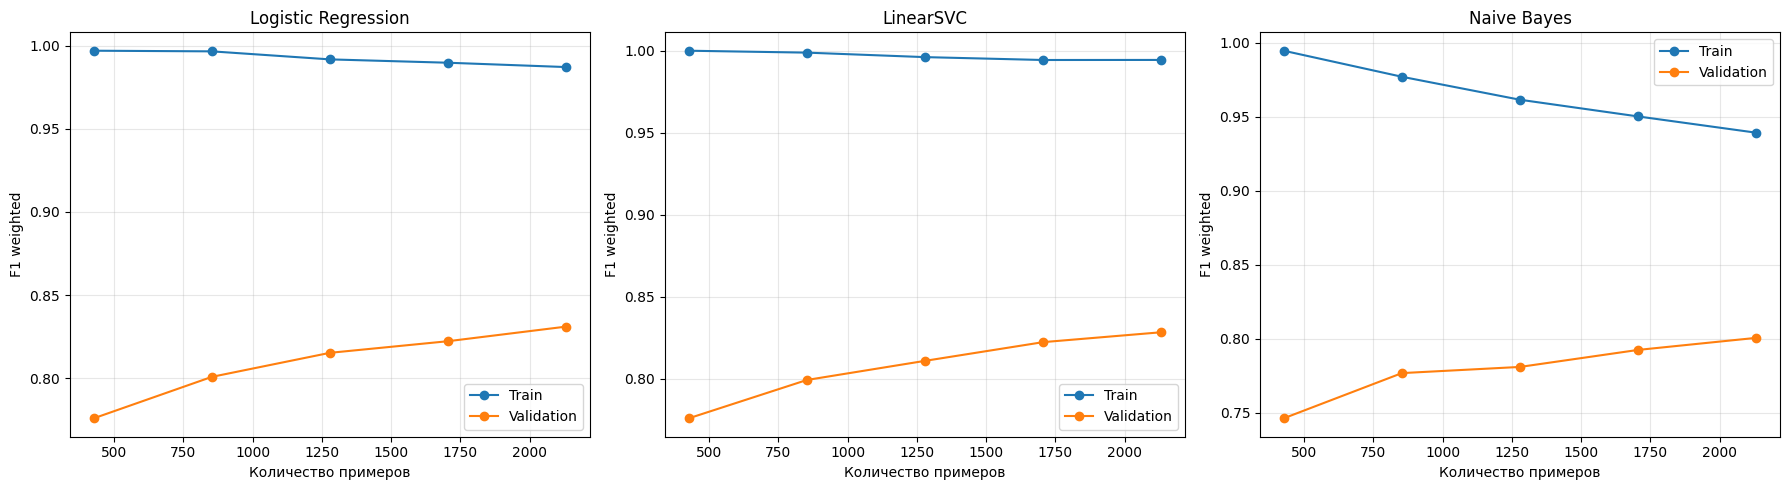

In [ ]:
top_models = sorted([(k, v) for k, v in results.items() if k != "DistilBERT"], key=lambda x: -x[1]["f1"])[:3]
fig, axes = plt.subplots(1, len(top_models), figsize=(6 * len(top_models), 5))
if len(top_models) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, tqdm(top_models, desc="Learning curves")):
    sizes, train_sc, val_sc = learning_curve(
        res["model"], X_train_bal, y_train_bal,
        train_sizes=np.linspace(0.2, 1.0, 5), cv=3,
        scoring="f1_weighted", n_jobs=-1
    )
    ax.plot(sizes, train_sc.mean(axis=1), marker="o", label="Train")
    ax.plot(sizes, val_sc.mean(axis=1), marker="o", label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Количество примеров")
    ax.set_ylabel("F1 weighted")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Итоговые метрики лабораторной работы

In [ ]:
success_rate = accuracy_score(y_test, results[best_name]["y_pred"])
precision = precision_score(y_test, results[best_name]["y_pred"], average="weighted", zero_division=0)
recall = recall_score(y_test, results[best_name]["y_pred"], average="weighted", zero_division=0)
f1 = f1_score(y_test, results[best_name]["y_pred"], average="weighted", zero_division=0)
topical_diversity = len(set(sum([v[:10] for v in topic_keywords.values()], []))) / (N_TOPICS * 10)
redundancy_rate = 1 - df["processed"].nunique() / len(df)
problem_resolution_rate = np.nan

if "response" in df.columns:
    problem_resolution_rate = df["response"].astype(str).str.contains("closed|resolved|explanation|relief", case=False, regex=True).mean()

final_metrics = pd.DataFrame({
    "metric": ["Success Rate", "Precision", "Recall", "F1-Score", "Topical Diversity", "Redundancy Rate", "Problem Resolution Rate"],
    "value": [success_rate, precision, recall, f1, topical_diversity, redundancy_rate, problem_resolution_rate]
})

final_metrics

,metric,value
0,Success Rate,0.835000
1,Precision,0.834819
2,Recall,0.835000
3,F1-Score,0.833934
4,Topical Diversity,0.720000
5,Redundancy Rate,0.022756
6,Problem Resolution Rate,NaN


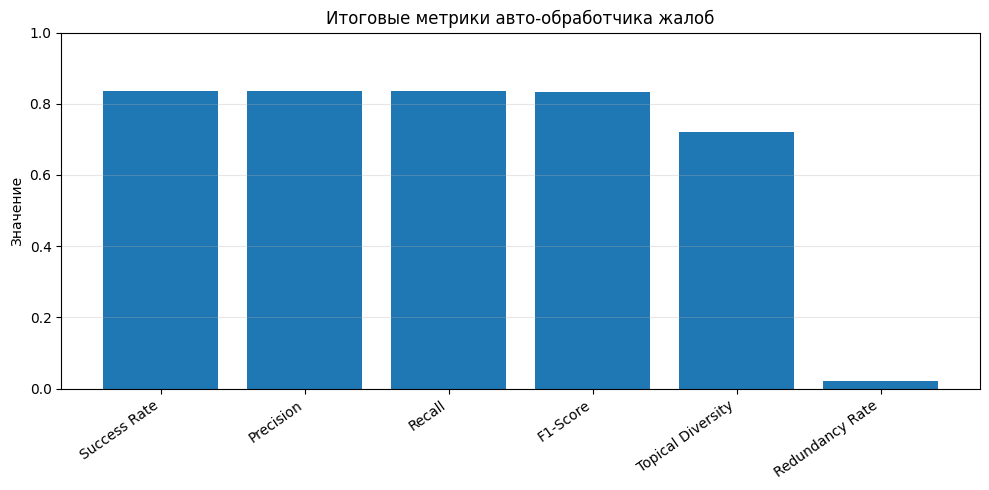

In [ ]:
plt.figure(figsize=(10, 5))
plot_metrics = final_metrics.dropna()
plt.bar(plot_metrics["metric"], plot_metrics["value"])
plt.title("Итоговые метрики авто-обработчика жалоб")
plt.ylabel("Значение")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Пример работы системы

In [ ]:
def predict_complaint(text):
    clean = clean_text(text)
    enc = tokenizer([clean], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    bert_model.eval()
    with torch.no_grad():
        out = bert_model(**enc)
        prob = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        pred = int(prob.argmax())
    return pd.DataFrame({"category": le.classes_, "probability": prob}).sort_values("probability", ascending=False).head(5)

example = "My credit report contains incorrect information and the company refuses to investigate my dispute."
predict_complaint(example)

,category,probability
2,Credit Reporting,0.778868
3,Debt Collection,0.170928
1,Credit Card Services,0.026098
4,Loans,0.019356
0,Bank Accounts and Services,0.004750
